# Smafa

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Konfigurasi Matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Tahap 1: Data Cleaning

In [4]:
INPUT_CSV = '../soil_dataset.csv'

# Load Data
df = pd.read_csv(INPUT_CSV)
print(f"Total baris awal: {len(df)}")

# Hapus Kolom Lama
cols_to_drop = ['ai_label', 'recommendation']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

# Filter missing values pada sensor
required_sensors = ['N', 'P', 'K', 'pH', 'EC', 'OC_est']
df.dropna(subset=required_sensors, inplace=True)

print(f"Total baris setelah cleaning: {len(df)}")
display(df.head())

Total baris awal: 2289
Total baris setelah cleaning: 2289


,id,timestamp,Hum,Temp,N,P,K,pH,EC,OC_est
0,6,2026-05-13 12:26:16.378126,96.7,32.6,40,138,131,5.4,376,0.617524
1,7,2026-05-13 12:27:18.586023,97.2,32.5,39,137,130,5.5,374,0.613870
2,8,2026-05-13 12:28:20.652853,96.7,32.5,39,137,130,5.6,374,0.610557
3,9,2026-05-13 12:29:22.916488,96.7,32.5,39,136,129,5.6,372,0.610557
4,10,2026-05-13 12:30:24.841741,97.2,32.4,38,136,129,5.7,371,0.606902


## Tahap 2: Labeling 

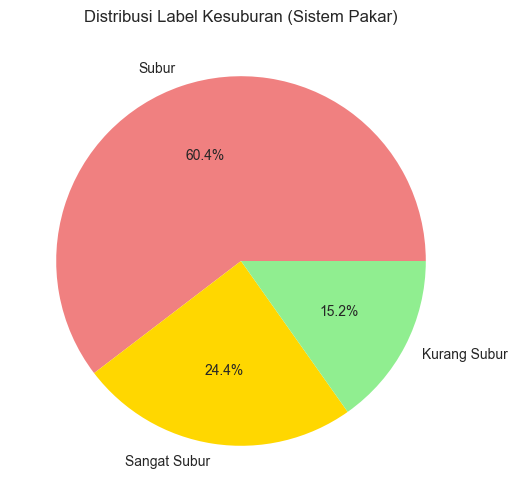

In [5]:
def score_N(N_mgkg):
    if N_mgkg < 100: return 0
    elif N_mgkg <= 200: return 1
    else: return 2

def score_P(P_mgkg):
    if P_mgkg < 100: return 0
    elif P_mgkg <= 300: return 1
    else: return 2

def score_K(K_mgkg):
    if K_mgkg < 100: return 0
    elif K_mgkg <= 300: return 1
    else: return 2

def score_OC(OC_pct):
    if OC_pct < 0.5: return 0
    elif OC_pct <= 1.0: return 1
    else: return 2

def score_pH(pH):
    if pH < 5.5 or pH > 7.5: return 0
    elif pH <= 6.5: return 1
    else: return 2

def score_EC(EC_uscm):
    if EC_uscm > 2000: return 0
    elif EC_uscm > 800: return 1
    else: return 2

def compute_label(row):
    total = (score_N(row['N']) + score_P(row['P']) + score_K(row['K']) +
             score_OC(row['OC_est']) + score_pH(row['pH']) + score_EC(row['EC']))
    if total <= 4: return 0
    elif total <= 8: return 1
    else: return 2

LABEL_NAME = {0: "Kurang Subur", 1: "Subur", 2: "Sangat Subur"}

df['Output'] = df.apply(compute_label, axis=1)
df['Label'] = df['Output'].map(LABEL_NAME)

# Visualisasi Distribusi
plt.figure(figsize=(6, 6))
df['Label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'gold', 'lightgreen'])
plt.title("Distribusi Label Kesuburan (Sistem Pakar)")
plt.ylabel("")
plt.show()

## Tahap 3: Model Training & Comparison
Melatih dan membandingkan 4 model Machine Learning: Random Forest, SVM, XGBoost, dan Neural Network.

--- HASIL PERBANDINGAN MODEL ---
Random Forest  : 99.34%
SVM            : 94.76%


C:\Users\DELL GAMING\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [12:45:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost        : 99.78%
Neural Network : 100.00%

Model Terbaik: Neural Network


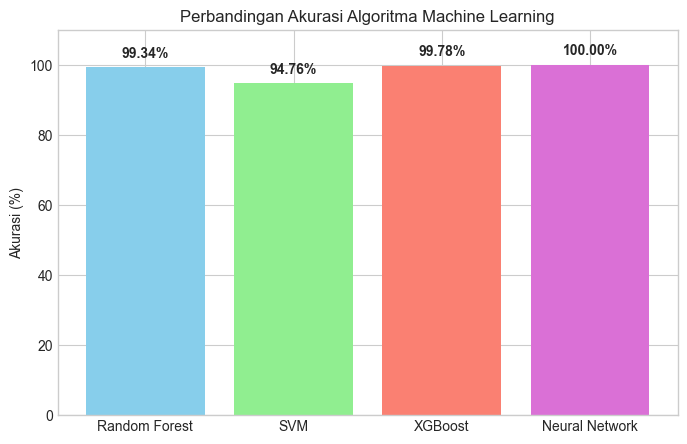

In [6]:
X = df[required_sensors]
y_raw = df['Label']

# Label Encoding
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

# Standarisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Inisialisasi Model
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = {}
best_model_name = ""
best_accuracy = 0
best_model_obj = None

print("--- HASIL PERBANDINGAN MODEL ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:<15}: {acc*100:.2f}%")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model_obj = model

print(f"\nModel Terbaik: {best_model_name}")

# Visualisasi Bar Chart
plt.figure(figsize=(8, 5))
colors = ['skyblue', 'lightgreen', 'salmon', 'orchid']
bars = plt.bar(results.keys(), [acc * 100 for acc in results.values()], color=colors)
plt.title('Perbandingan Akurasi Algoritma Machine Learning')
plt.ylabel('Akurasi (%)')
plt.ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.show()

## Tahap 4: Detail Evaluasi Model Terbaik
Memvisualisasikan *Confusion Matrix* dan *Feature Importance* (jika algoritma berbasis tree).

Classification Report:
              precision    recall  f1-score   support

Kurang Subur       1.00      1.00      1.00        70
Sangat Subur       1.00      1.00      1.00       112
       Subur       1.00      1.00      1.00       276

    accuracy                           1.00       458
   macro avg       1.00      1.00      1.00       458
weighted avg       1.00      1.00      1.00       458



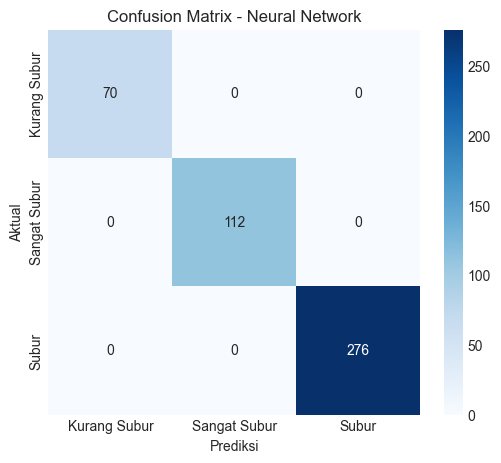

Model terbaik bukan berbasis pohon, lewati plot feature importance.


In [7]:
y_pred_best = best_model_obj.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# Feature Importance (Hanya untuk RF / XGBoost)
if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 5))
    plt.title(f"Feature Importance ({best_model_name})")
    plt.bar(range(len(required_sensors)), importances[indices], color="coral", align="center")
    plt.xticks(range(len(required_sensors)), [required_sensors[i] for i in indices])
    plt.ylabel("Tingkat Kepentingan")
    plt.show()
else:
    print("Model terbaik bukan berbasis pohon, lewati plot feature importance.")